# Forecast de la demanda energetica

Notebook de diagnostico, ajuste y prediccion para la demanda electrica horaria de Austria.

In [102]:
# Si el paquete local no esta instalado en el kernel, descomenta esta linea.
# %pip install -e .

In [103]:
from pathlib import Path
import sys
import logging
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from cyclical_fractional_test import (
    CyclicalFractionalModel,
    CyclicalTestConfig,
    compute_autocorrelogram,
    compute_periodogram,
)
from cyclical_fractional_test.regression import DEFAULT_BETA_SIGNIFICANCE_CRITICAL_VALUE

logging.basicConfig(level=logging.WARNING, format="%(levelname)s:%(name)s:%(message)s", force=True)

DATA_DIR = REPO_ROOT / "data"
FIG_DIR = REPO_ROOT / "figures" / "energy_demand"
# Carpeta de cache nueva: el preprocesado replica notebook.ipynb (tendencia sobre la serie
# completa + split 80%); los modelos antiguos (train-trend / 70%) ya no son validos.
MODEL_DIR = REPO_ROOT / "models" / "energy_demand_notebook_match"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

FORCE_REFIT = False

## Datos horarios de demanda electrica

In [104]:
ENERGY_FILE = DATA_DIR / "energy_demand.csv"
COLUMN = "AT_load_actual_entsoe_transparency"
N_OBSERVATIONS = 50400
TRAIN_RATIO = 0.70

energy_raw = pd.read_csv(ENERGY_FILE, usecols=["utc_timestamp", COLUMN])
energy_raw["utc_timestamp"] = pd.to_datetime(energy_raw["utc_timestamp"], utc=True)
energy_raw[COLUMN] = pd.to_numeric(energy_raw[COLUMN], errors="coerce")
energy_raw = (
    energy_raw
    .dropna(subset=["utc_timestamp", COLUMN])
    .sort_values("utc_timestamp")
    .reset_index(drop=True)
)

if len(energy_raw) < N_OBSERVATIONS:
    raise ValueError(f"Se esperaban al menos {N_OBSERVATIONS} observaciones y solo hay {len(energy_raw)}.")

energy = energy_raw.iloc[:N_OBSERVATIONS].copy()
dates = energy["utc_timestamp"].reset_index(drop=True)
y_raw = energy[COLUMN].to_numpy(dtype=float)
T = len(y_raw)
T_train = int(TRAIN_RATIO * T)
T_test = T - T_train

print(f"T total: {T}")
print(f"T train: {T_train}")
print(f"T test: {T_test}")
print(f"Periodo cubierto: {dates.iloc[0]} - {dates.iloc[-1]}")
print(f"Min/Max: {y_raw.min():.1f} / {y_raw.max():.1f} MW")
display(energy.head())
display(energy.tail())

T total: 50400
T train: 35280
T test: 15120
Periodo cubierto: 2015-01-01 00:00:00+00:00 - 2020-09-30 23:00:00+00:00
Min/Max: 664.0 / 10803.0 MW


,utc_timestamp,AT_load_actual_entsoe_transparency
0,2015-01-01 00:00:00+00:00,5946.0
1,2015-01-01 01:00:00+00:00,5726.0
2,2015-01-01 02:00:00+00:00,5347.0
3,2015-01-01 03:00:00+00:00,5249.0
4,2015-01-01 04:00:00+00:00,5309.0


,utc_timestamp,AT_load_actual_entsoe_transparency
50395,2020-09-30 19:00:00+00:00,6661.0
50396,2020-09-30 20:00:00+00:00,6336.0
50397,2020-09-30 21:00:00+00:00,5932.0
50398,2020-09-30 22:00:00+00:00,5628.0
50399,2020-09-30 23:00:00+00:00,5395.0


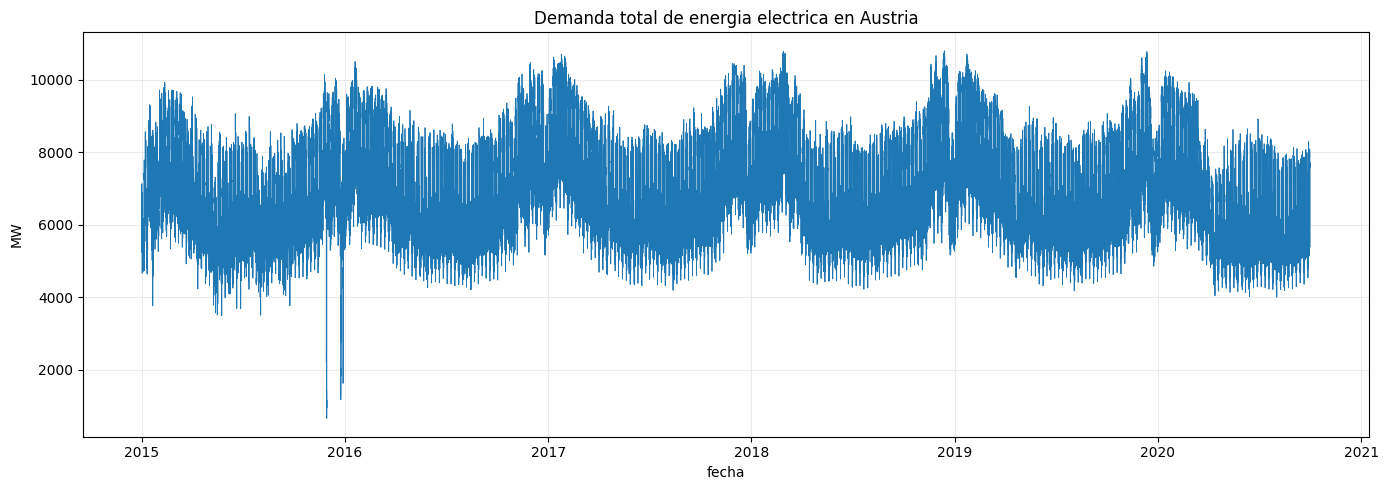

In [143]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, y_raw, linewidth=0.6)
ax.set_title("Demanda total de energia electrica en Austria")
ax.set_xlabel("fecha")
ax.set_ylabel("MW")
fig.tight_layout()
fig.savefig(FIG_DIR / "austria-load-plot.png", dpi=200, bbox_inches="tight")
plt.show()

## Analisis preliminar: serie detrendida, periodograma y autocorrelograma

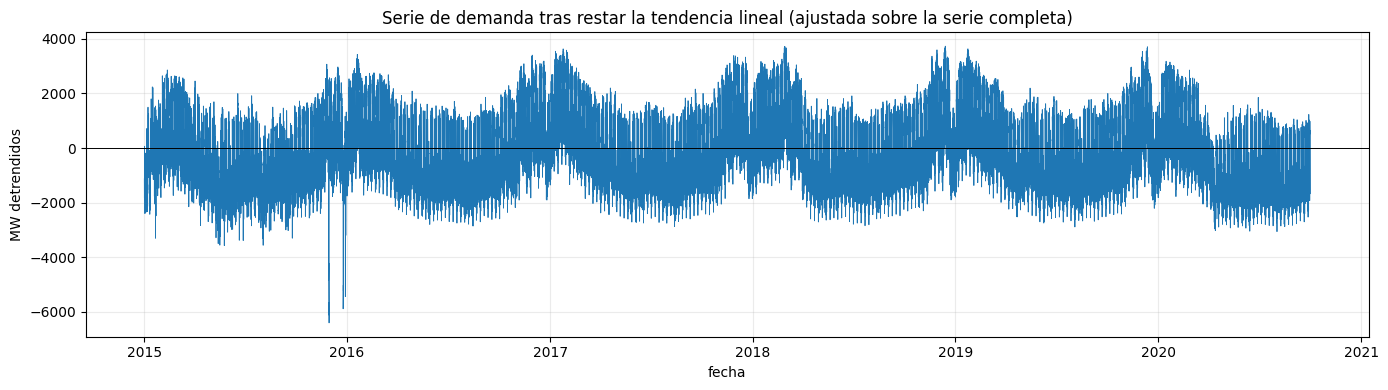

In [106]:
def fit_linear_trend(values):
    t = np.arange(len(values), dtype=float)
    return np.polyfit(t, np.asarray(values, dtype=float), deg=1)


def evaluate_linear_trend(coefficients, n_points):
    return np.polyval(np.asarray(coefficients, dtype=float), np.arange(n_points, dtype=float))


def detrend_linear(values):
    """Replica exacta de `detrend_linear` en notebook.ipynb: ajusta la tendencia lineal
    (pendiente + intercepto) sobre la SERIE COMPLETA y la resta. (En el original el parametro
    `frac` se ignora por `train_series = y[:]`, de modo que la tendencia usa toda la serie.)
    Devuelve (serie_detrendida, coeficientes, tendencia_completa)."""
    values = np.asarray(values, dtype=float)
    coefficients = fit_linear_trend(values)
    trend = evaluate_linear_trend(coefficients, len(values))
    return values - trend, coefficients, trend


# Fuente unica de verdad para todo el notebook. `trend_full` es la misma tendencia que se
# sumara despues para reconstruir la prediccion en la escala original (MW).
y_analysis, trend_coefficients, trend_full = detrend_linear(y_raw)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, y_analysis, color="tab:blue", linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Serie de demanda tras restar la tendencia lineal (ajustada sobre la serie completa)")
ax.set_xlabel("fecha")
ax.set_ylabel("MW detrendidos")
fig.tight_layout()
plt.show()

In [107]:
def periodogram_table(values):
    lambdas, intensities = compute_periodogram(values)
    half = len(intensities) // 2
    R = np.arange(half)
    periods = np.full(half, np.inf, dtype=float)
    periods[1:] = len(values) / R[1:]
    return pd.DataFrame({
        "R": R,
        "w_r_rad": 2.0 * np.pi * R / len(values),
        "lambda": lambdas[:half],
        "I": intensities[:half],
        "I_x_1e9": intensities[:half] / 1e9,
        "period_hours": periods,
    })

periodogram_full = periodogram_table(y_analysis)

ENERGY_PEAKS_FULL = {
    6: "Ciclo anual",
    300: "Ciclo semanal",
    600: "Segundo armonico semanal",
    2100: "Ciclo diario",
    4200: "Segundo armonico diario",
}

peak_rows = []
for R, component in ENERGY_PEAKS_FULL.items():
    row = periodogram_full.loc[periodogram_full["R"] == R].iloc[0].to_dict()
    row["componente"] = component
    peak_rows.append(row)

peak_table = pd.DataFrame(peak_rows)[["R", "w_r_rad", "period_hours", "componente", "I_x_1e9"]]
display(peak_table)

print("Picos principales del periodograma completo:")
display(periodogram_full.sort_values("I", ascending=False).head(15))

,R,w_r_rad,period_hours,componente,I_x_1e9
0,6.0,0.000748,8400.0,Ciclo anual,1.199299
1,300.0,0.037400,168.0,Ciclo semanal,1.036687
2,600.0,0.074800,84.0,Segundo armonico semanal,0.300771
3,2100.0,0.261799,24.0,Ciclo diario,2.703447
4,4200.0,0.523599,12.0,Segundo armonico diario,0.561233


Picos principales del periodograma completo:


,R,w_r_rad,lambda,I,I_x_1e9,period_hours
2100,2100,0.261799,0.261799,2.703447e+09,2.703447,24.000000
6,6,0.000748,0.000748,1.199299e+09,1.199299,8400.000000
300,300,0.037400,0.037400,1.036687e+09,1.036687,168.000000
4200,4200,0.523599,0.523599,5.612328e+08,0.561233,12.000000
600,600,0.074800,0.074800,3.007711e+08,0.300771,84.000000
1,1,0.000125,0.000125,1.808810e+08,0.180881,50400.000000
5,5,0.000623,0.000623,1.057931e+08,0.105793,10080.000000
1800,1800,0.224399,0.224399,9.173342e+07,0.091733,28.000000
1500,1500,0.187000,0.187000,6.584010e+07,0.065840,33.600000
12,12,0.001496,0.001496,5.653454e+07,0.056535,4200.000000


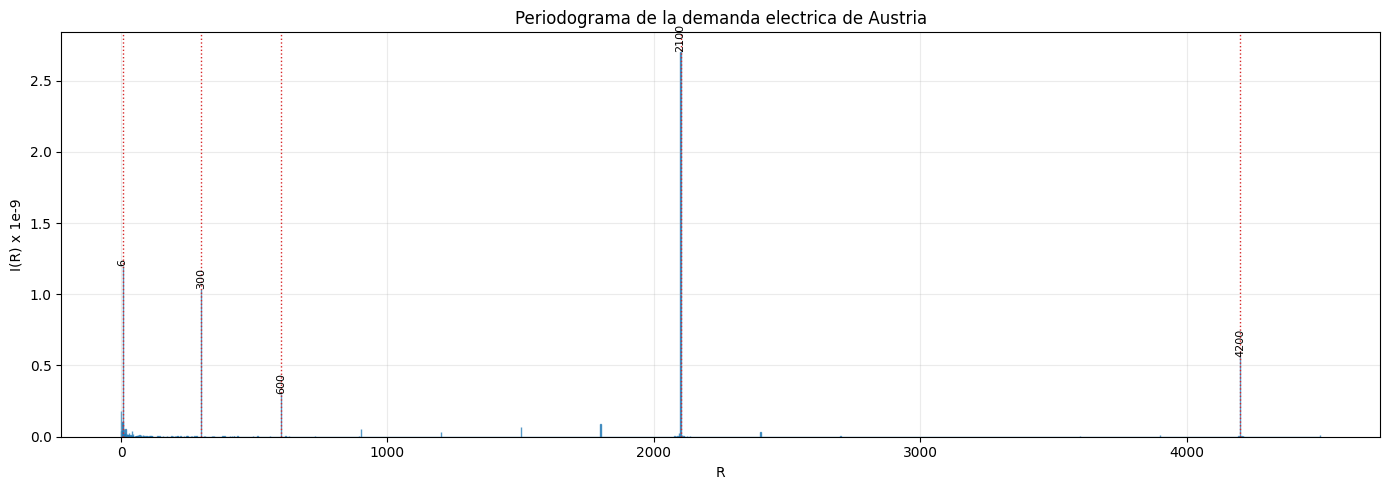

In [108]:
R_MAX_PLOT = 4500
plot_df = periodogram_full.iloc[1:R_MAX_PLOT + 1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(plot_df["R"], plot_df["I_x_1e9"], width=1.0, color="tab:blue", edgecolor="tab:blue", alpha=0.75)
for R, label in ENERGY_PEAKS_FULL.items():
    y_value = float(periodogram_full.loc[periodogram_full["R"] == R, "I_x_1e9"].iloc[0])
    ax.axvline(R, color="tab:red", linestyle=":", linewidth=1.0)
    ax.text(R, y_value, str(R), rotation=90, va="bottom", ha="center", fontsize=8)
ax.set_title("Periodograma de la demanda electrica de Austria")
ax.set_xlabel("R")
ax.set_ylabel("I(R) x 1e-9")
fig.tight_layout()
fig.savefig(FIG_DIR / "austria-load-periodogram.png", dpi=200, bbox_inches="tight")
plt.show()

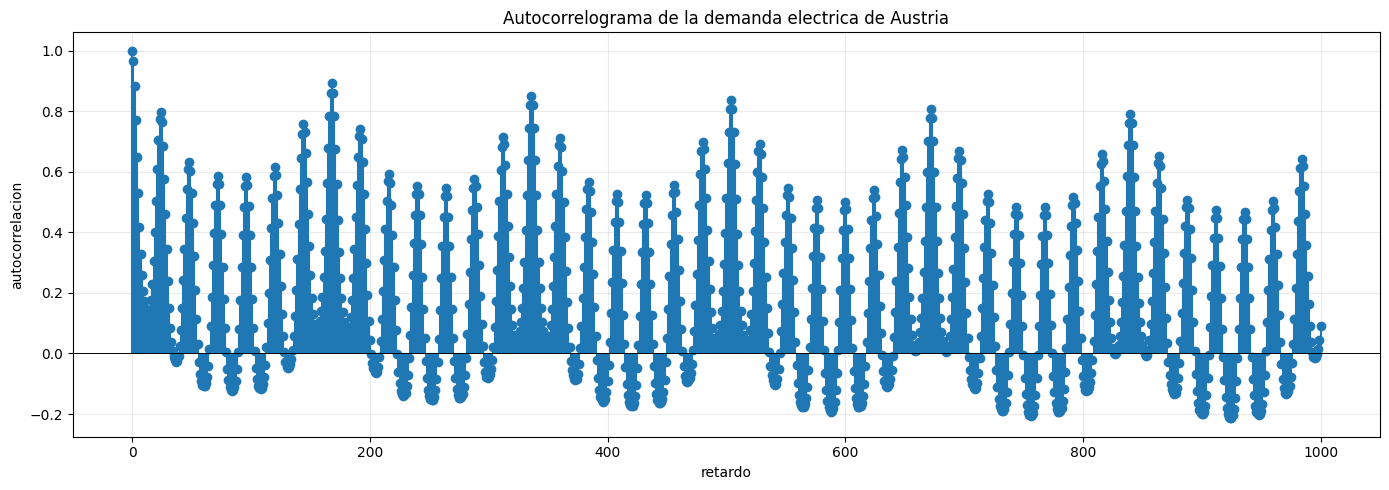

In [109]:
MAX_LAG = 1000
lags, autocorr = compute_autocorrelogram(y_analysis, max_lag=MAX_LAG)

fig, ax = plt.subplots(figsize=(14, 5))
ax.stem(lags, autocorr, basefmt=" ")
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Autocorrelograma de la demanda electrica de Austria")
ax.set_xlabel("retardo")
ax.set_ylabel("autocorrelacion")
fig.tight_layout()
fig.savefig(FIG_DIR / "austria-load-autocorrelogram.png", dpi=200, bbox_inches="tight")
plt.show()

## Preparacion del ajuste predictivo

**Preprocesado (replica exacta de `detrend_linear` en `notebook.ipynb`):** la tendencia lineal se
ajusta sobre la **serie completa** (`fit_linear_trend(y_raw)`) y se resta de toda la serie
(`trend_full`). El modelo se ajusta sobre la serie detrendida `y_train_model` con **split 80%**
(`T_train = int(0.70 * T) = 40320`), igual que `notebook.ipynb`. La tendencia incluye el intercepto,
por lo que absorbe tambien el nivel medio: no hace falta un demean adicional.

**Reconstruccion:** la prediccion vuelve a la escala original (MW) sumando la tendencia extraida,
`prediccion = model.predict(n) + trend_full` (ver `predict_and_score`).

> Con esto `y_train` es **identico bit a bit** al de `notebook.ipynb`, de modo que los ciclos,
> `test_value` y RMSE deben coincidir para la misma configuracion.

In [110]:
y_train_raw = y_raw[:T_train]
y_test_raw = y_raw[T_train:]

# Reutilizamos la tendencia estimada con el train (definida en el analisis preliminar):
# `trend_full` ya se resto sobre toda la serie y es la que sumaremos de vuelta para
# reconstruir la escala original. La serie de entrenamiento del modelo es la detrendida.
y_train_model = y_train_raw - trend_full[:T_train]
y_model_full = y_raw - trend_full

R_ANNUAL = int(round(T_train / 8400))
R_WEEKLY = int(round(T_train / 168))
R_WEEKLY_H2 = int(round(T_train / 84))
R_DAILY = int(round(T_train / 24))
R_DAILY_H2 = int(round(T_train / 12))

print("R esperados sobre train:")
print({
    "anual": R_ANNUAL,
    "semanal": R_WEEKLY,
    "armonico_semanal": R_WEEKLY_H2,
    "diario": R_DAILY,
    "medio_dia": R_DAILY_H2,
})
print({
    "periodo_anual_h": T_train / R_ANNUAL,
    "periodo_semanal_h": T_train / R_WEEKLY,
    "periodo_diario_h": T_train / R_DAILY,
    "periodo_medio_dia_h": T_train / R_DAILY_H2,
})

R esperados sobre train:
{'anual': 4, 'semanal': 210, 'armonico_semanal': 420, 'diario': 1470, 'medio_dia': 2940}
{'periodo_anual_h': 8820.0, 'periodo_semanal_h': 168.0, 'periodo_diario_h': 24.0, 'periodo_medio_dia_h': 12.0}


In [111]:
ANNUAL_IGNORE_RS = (R_ANNUAL,)
WEEKLY_IGNORE_RS = (R_WEEKLY,)
WEEKLY_HARMONIC_IGNORE_RS = (R_WEEKLY_H2,)

print("R excluidos para el ciclo anual:", ANNUAL_IGNORE_RS)
print("R excluidos para el ciclo semanal:", WEEKLY_IGNORE_RS)
print("R excluidos para el armonico semanal:", WEEKLY_HARMONIC_IGNORE_RS)

R excluidos para el ciclo anual: (4,)
R excluidos para el ciclo semanal: (210,)
R excluidos para el armonico semanal: (420,)


## Funciones auxiliares para tests, betas y prediccion

In [132]:
def _cycle_rows(candidate, T_ref):
    rows = []
    for i, cycle in enumerate(candidate.cycles, start=1):
        period = np.inf if cycle.R == 0 else T_ref / cycle.R
        rows.append({
            "cycle": i,
            "R": int(cycle.R),
            "D": float(cycle.D),
            "period_hours": period,
            "period_days": period / 24 if np.isfinite(period) else np.inf,
        })
    return rows


def summarize_test_result(model, label, T_ref):
    result = model.result_
    best = result.best_result
    print(label)
    print(f"n_candidates_evaluated: {result.n_candidates_evaluated}")
    print(f"r_peak: {result.r_peak}")
    print(f"r_candidates: {result.r_candidates}")
    print(f"test_value: {best.test_value:.6f}")
    print(f"test_star_value: {best.test_star_value:.6f}")
    print(f"variance_time: {best.variance_time:.6f}")
    print(f"variance_frequency: {best.variance_frequency:.6f}")
    print(f"betas: {np.round(best.betas, 6)}")
    if len(best.ar_coefficients):
        print(f"AR coefficients: {np.round(best.ar_coefficients, 6)}")
    display(pd.DataFrame(_cycle_rows(best, T_ref)))


def top_candidates_table(result, T_ref, n=5):
    rows = []
    for rank, candidate in enumerate(result.top_k_results[:n], start=1):
        row = {
            "rank": rank,
            "test_value": candidate.test_value,
            "abs_test_value": abs(candidate.test_value),
            "test_star_value": candidate.test_star_value,
            "abs_test_star_value": abs(candidate.test_star_value),
            "xa": candidate.xa,
            "xaa": candidate.xaa,
        }
        for i, cycle in enumerate(candidate.cycles, start=1):
            row[f"R_{i}"] = int(cycle.R)
            row[f"D_{i}"] = float(cycle.D)
            row[f"period_h_{i}"] = np.inf if cycle.R == 0 else T_ref / cycle.R
        rows.append(row)
    return pd.DataFrame(rows)


def beta_names(config):
    names = []
    if config.include_intercept:
        names.append("Intercepto")
    if config.chebyshev_orders is None:
        orders = range(1, config.n_deterministic_cycles + 1)
    else:
        orders = config.chebyshev_orders
    names.extend([f"P_{order}(t)" for order in orders])
    return names


def beta_significance_table(model, critical_value=DEFAULT_BETA_SIGNIFICANCE_CRITICAL_VALUE):
    sig = model.detect_beta_significance(critical_value=critical_value)
    names = beta_names(model.config)
    if len(names) != len(sig.betas):
        names = [f"beta_{i}" for i in range(len(sig.betas))]
    return pd.DataFrame({
        "coeficiente": names,
        "beta": sig.betas,
        "std_error": sig.standard_errors,
        "t_stat": sig.t_statistics,
        "critical_value": sig.critical_value,
        "significativo": sig.significant,
    })


def fit_or_load_model(model_id, config):
    artifact_path = MODEL_DIR / f"{model_id}.pkl"
    if artifact_path.exists() and not FORCE_REFIT:
        with artifact_path.open("rb") as handle:
            artifact = pickle.load(handle)
        print(f"Modelo cargado: {artifact_path}")
        return artifact["model"]

    print(f"Ajustando {model_id}...")
    started = time.perf_counter()
    model = CyclicalFractionalModel(config=config).fit(y_train_model)
    elapsed = time.perf_counter() - started
    with artifact_path.open("wb") as handle:
        pickle.dump({
            "model": model,
            "config": config,
            "trend_coefficients": trend_coefficients,
            "train_size": T_train,
            "elapsed_seconds": elapsed,
        }, handle)
    print(f"Ajuste completado en {elapsed / 60:.2f} min. Guardado en {artifact_path}")
    return model


def predict_and_score(model, figure_prefix, full_figure_name, close_figure_name, title):
    prediction_model_scale = model.predict(T)
    prediction = prediction_model_scale + trend_full
    errors = y_raw[T_train:] - prediction[T_train:]
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    mae = float(np.mean(np.abs(errors)))

    print(f"RMSE: {rmse:.3f}")
    print(f"MAE:  {mae:.3f}")

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, y_raw, label="observado", color="black", linewidth=0.6)
    ax.plot(dates, prediction, label="prediccion", color="tab:red", linestyle="--", linewidth=0.7)
    ax.axvline(dates.iloc[T_train - 1], color="gray", linestyle=":", linewidth=1.2, label="fin del train")
    # ax.set_title(f"{title}: serie completa")
    ax.set_xlabel("fecha")
    ax.set_ylabel("MW")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / full_figure_name, dpi=200, bbox_inches="tight")
    plt.show()

    close_start = max(0, T_train - 7 * 24)
    close_end = min(T, T_train + 21 * 24)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates.iloc[close_start:close_end], y_raw[close_start:close_end], label="observado", color="black", linewidth=0.7)
    ax.plot(dates.iloc[close_start:close_end], prediction[close_start:close_end], label="prediccion", color="tab:red", linestyle="--", linewidth=1.0)
    ax.axvline(dates.iloc[T_train - 1], color="gray", linestyle=":", linewidth=1.2, label="fin del train")
    # ax.set_title(f"{title}: detalle validacion")
    ax.set_xlabel("fecha")
    ax.set_ylabel("MW")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / close_figure_name, dpi=200, bbox_inches="tight")
    plt.show()

    return {"prediction": prediction, "rmse": rmse, "mae": mae, "figure_prefix": figure_prefix}

## Especificacion inicial: tres ciclos estocasticos

In [140]:
energy_3_0_config = CyclicalTestConfig(
    n_deterministic_cycles=0,
    include_intercept=True,
    top_k=5,
    statistic_mode="test",
    stochastic_cycle_mode="multi_cycle",
    n_stochastic_cycles=3,
    exclude_zero_frequency=True,
    error_model="white_noise",
    d_search_strategy="adaptive",
)

energy_3_0_model = fit_or_load_model("energy_model_3_0", energy_3_0_config)
summarize_test_result(energy_3_0_model, "Test inicial: tres ciclos estocasticos", T_train)
display(top_candidates_table(energy_3_0_model.result_, T_train, n=5))

Ajustando energy_model_3_0...
Ajuste completado en 33.20 min. Guardado en /Users/asierlanda/OneDrive - KPMG/Desktop/master/TFM/log_memory_cycles/models/energy_demand_notebook_match/energy_model_3_0.pkl
Test inicial: tres ciclos estocasticos
n_candidates_evaluated: 4940
r_peak: 1470
r_candidates: [1470    4  210]
test_value: -0.008989
test_star_value: -0.009053
variance_time: 64702.067094
variance_frequency: 64248.651552
betas: [25.252348]


,cycle,R,D,period_hours,period_days
0,1,1470,0.61,24.0,1.0
1,2,4,0.01,8820.0,367.5
2,3,210,0.18,168.0,7.0


,rank,test_value,abs_test_value,test_star_value,abs_test_star_value,xa,xaa,R_1,D_1,period_h_1,R_2,D_2,period_h_2,R_3,D_3,period_h_3
0,1,-0.008989,0.008989,-0.009053,0.009053,-22.012999,50.537042,1470,0.61,24.0,4,0.01,8820.0,210,0.18,168.0
1,2,-0.010432,0.010432,-0.010501,0.010501,-25.486319,50.537042,1470,0.62,24.0,4,0.02,8820.0,210,0.16,168.0
2,3,0.012787,0.012787,0.012830,0.012830,31.077210,50.537042,1470,0.58,24.0,4,0.05,8820.0,210,0.16,168.0
3,4,-0.018220,0.018220,-0.018293,0.018293,-44.541553,50.537042,1470,0.55,24.0,4,0.02,8820.0,210,0.22,168.0
4,5,-0.024887,0.024887,-0.024974,0.024974,-60.587470,50.537042,1470,0.57,24.0,4,0.04,8820.0,210,0.18,168.0


In [141]:
# Significatividad de los betas del test inicial.
display(beta_significance_table(energy_3_0_model))

,coeficiente,beta,std_error,t_stat,critical_value,significativo
0,Intercepto,25.252348,26.12329,0.96666,1.645,False


RMSE: 1067.223
MAE:  868.797


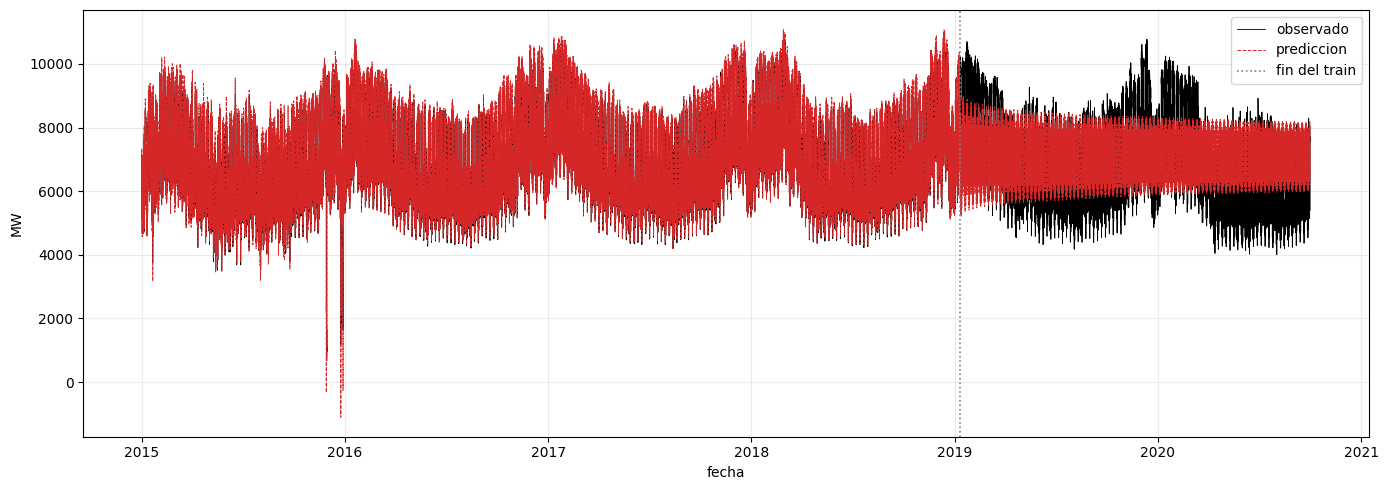

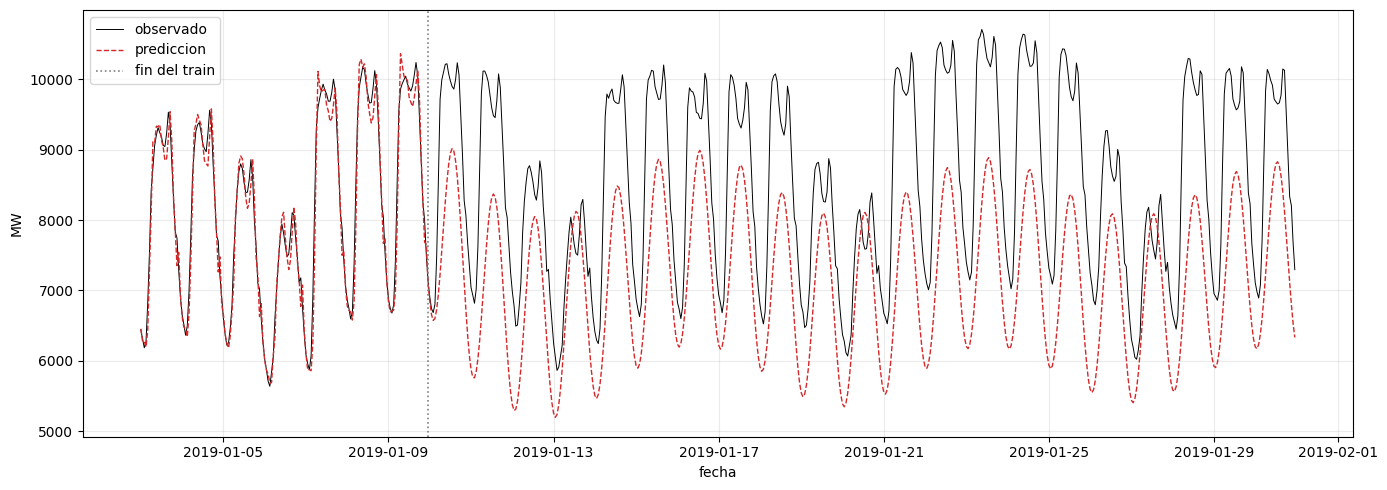

In [142]:
energy_3_0_prediction = predict_and_score(
    energy_3_0_model,
    "energy_3_0",
    "energy_model_3_0_fullpred.png",
    "energy_model_3_0_closepred.png",
    "Modelo con tres ciclos estocasticos",
)

## Incorporacion del ciclo anual como termino determinista de grado 8

In [137]:
energy_2_8_9_config = CyclicalTestConfig(
    n_deterministic_cycles=0,
    include_intercept=False,
    chebyshev_orders=(8,9,),
    top_k=5,
    statistic_mode="test",
    stochastic_cycle_mode="multi_cycle",
    n_stochastic_cycles=2,
    ignored_stochastic_rs=(3,4,5),
    exclude_zero_frequency=True,
    error_model="white_noise",
    d_search_strategy="adaptive",
)

energy_2_8_9_model = fit_or_load_model("energy_model_2_8_9", energy_2_8_9_config)
summarize_test_result(energy_2_8_9_model, "Test con dos ciclos estocasticos y P_8(t)", T_train)
display(top_candidates_table(energy_2_8_9_model.result_, T_train, n=5))

Ajustando energy_model_2_8_9...
Ajuste completado en 2.12 min. Guardado en /Users/asierlanda/OneDrive - KPMG/Desktop/master/TFM/log_memory_cycles/models/energy_demand_notebook_match/energy_model_2_8_9.pkl
Test con dos ciclos estocasticos y P_8(t)
n_candidates_evaluated: 481
r_peak: 1470
r_candidates: [1470  210]
test_value: 0.047880
test_star_value: 0.047887
variance_time: 64439.643495
variance_frequency: 64430.671673
betas: [367.50336  -87.529008]


,cycle,R,D,period_hours,period_days
0,1,1470,0.52,24.0,1.0
1,2,210,0.27,168.0,7.0


,rank,test_value,abs_test_value,test_star_value,abs_test_star_value,xa,xaa,R_1,D_1,period_h_1,R_2,D_2,period_h_2
0,1,0.047880,0.047880,0.047887,0.047887,75.951348,21.378853,1470,0.52,24.0,210,0.27,168.0
1,2,-0.070391,0.070391,-0.070399,0.070399,-111.799774,21.378853,1470,0.51,24.0,210,0.28,168.0
2,3,0.075580,0.075580,0.075635,0.075635,119.005499,21.378853,1470,0.62,24.0,210,0.18,168.0
3,4,0.189494,0.189494,0.189525,0.189525,300.236677,21.378853,1470,0.53,24.0,210,0.26,168.0
4,5,0.209393,0.209393,0.209789,0.209789,330.113157,21.378853,1470,0.68,24.0,210,0.13,168.0


In [138]:
# Significatividad de los betas del test con P_8(t).
display(beta_significance_table(energy_2_8_9_model))

,coeficiente,beta,std_error,t_stat,critical_value,significativo
0,P_8(t),367.503360,22.344999,16.446784,1.645,True
1,P_9(t),-87.529008,22.345583,-3.917061,1.645,True


RMSE: 853.732
MAE:  691.104


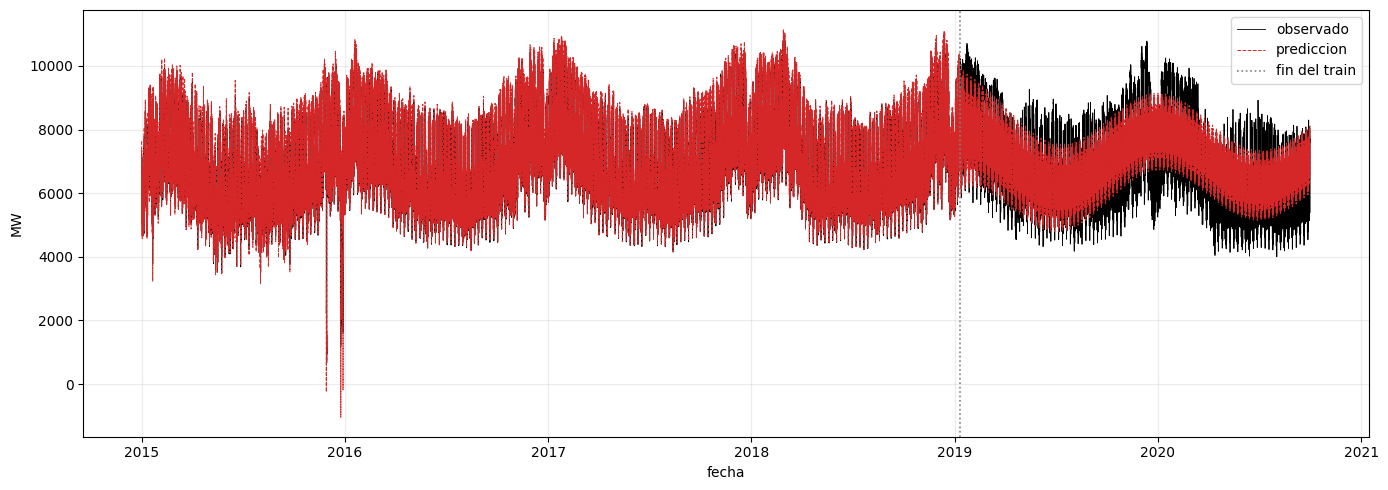

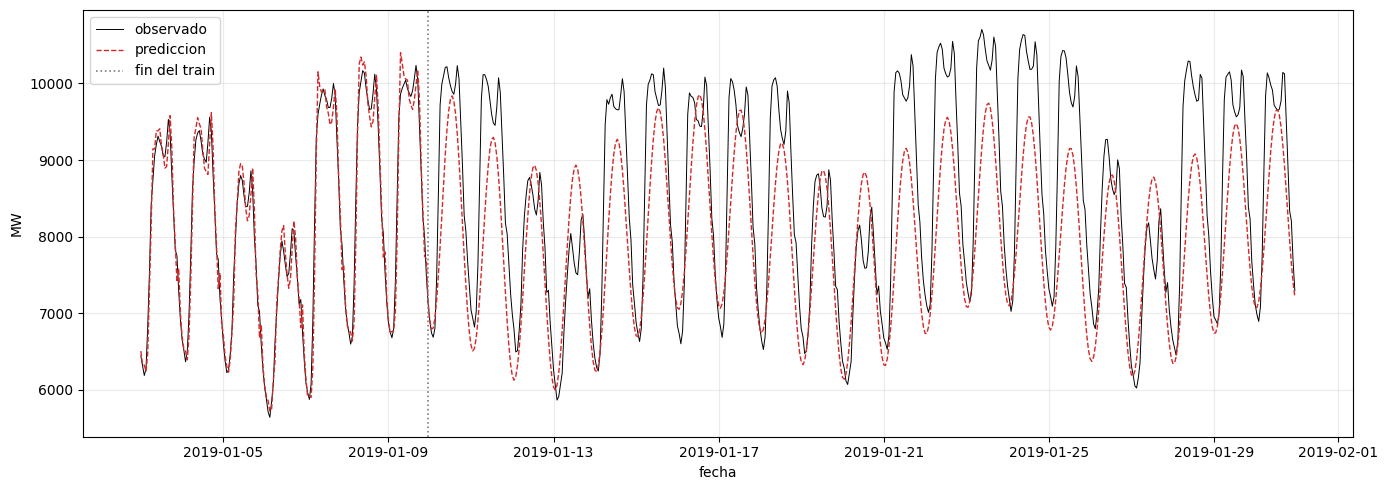

In [139]:
energy_2_8_9_prediction = predict_and_score(
    energy_2_8_9_model,
    "energy_2_8_9",
    "energy_model_2_8_9_fullpred.png",
    "energy_model_2_8_9_closepred.png",
    "Modelo con dos ciclos estocasticos y P_8(t)",
)

## Incorporacion del armonico de medio dia: tres ciclos estocasticos y P_8(t)

In [119]:
energy_3_8_9_config = CyclicalTestConfig(
    n_deterministic_cycles=0,
    include_intercept=True,
    chebyshev_orders=(8,9,),
    top_k=5,
    statistic_mode="test",
    stochastic_cycle_mode="multi_cycle",
    n_stochastic_cycles=3,
    ignored_stochastic_rs=(3,4,5),
    exclude_zero_frequency=True,
    error_model="white_noise",
    d_search_strategy="adaptive",
)

energy_3_8_9_model = fit_or_load_model("energy_model_3_8", energy_3_8_9_config)
summarize_test_result(energy_3_8_9_model, "Test con tres ciclos estocasticos y P_8(t)", T_train)
display(top_candidates_table(energy_3_8_9_model.result_, T_train, n=5))

Ajustando energy_model_3_8...
Ajuste completado en 91.27 min. Guardado en /Users/asierlanda/OneDrive - KPMG/Desktop/master/TFM/log_memory_cycles/models/energy_demand_notebook_match/energy_model_3_8.pkl
Test con tres ciclos estocasticos y P_8(t)
n_candidates_evaluated: 8189
r_peak: 1470
r_candidates: [1470  210 2940]
test_value: 0.023427
test_star_value: 0.023611
variance_time: 48624.656087
variance_frequency: 48244.249940
betas: [ 33.370997 394.087042 -61.255872]


,cycle,R,D,period_hours,period_days
0,1,1470,0.32,24.0,1.0
1,2,210,0.19,168.0,7.0
2,3,2940,0.21,12.0,0.5


,rank,test_value,abs_test_value,test_star_value,abs_test_star_value,xa,xaa,R_1,D_1,period_h_1,R_2,D_2,period_h_2,R_3,D_3,period_h_3
0,1,0.023427,0.023427,0.023611,0.023611,38.155163,39.582288,1470,0.32,24.0,210,0.19,168.0,2940,0.21,12.0
1,2,-0.037055,0.037055,-0.038064,0.038064,-71.570159,39.582288,1470,0.46,24.0,210,0.04,168.0,2940,0.36,12.0
2,3,0.037576,0.037576,0.038066,0.038066,65.177471,39.582288,1470,0.46,24.0,210,0.10,168.0,2940,0.21,12.0
3,4,0.044243,0.044243,0.045469,0.045469,86.221687,39.582288,1470,0.44,24.0,210,0.04,168.0,2940,0.39,12.0
4,5,0.046200,0.046200,0.046515,0.046515,77.342815,39.582288,1470,0.31,24.0,210,0.15,168.0,2940,0.31,12.0


In [120]:
# Significatividad de los betas del test con tres ciclos estocasticos y P_8(t).
display(beta_significance_table(energy_3_8_9_model))

,coeficiente,beta,std_error,t_stat,critical_value,significativo
0,Intercepto,33.370997,12.725003,2.622475,1.645,True
1,P_8(t),394.087042,8.983066,43.869991,1.645,True
2,P_9(t),-61.255872,8.983241,-6.818906,1.645,True


RMSE: 884.776
MAE:  745.453


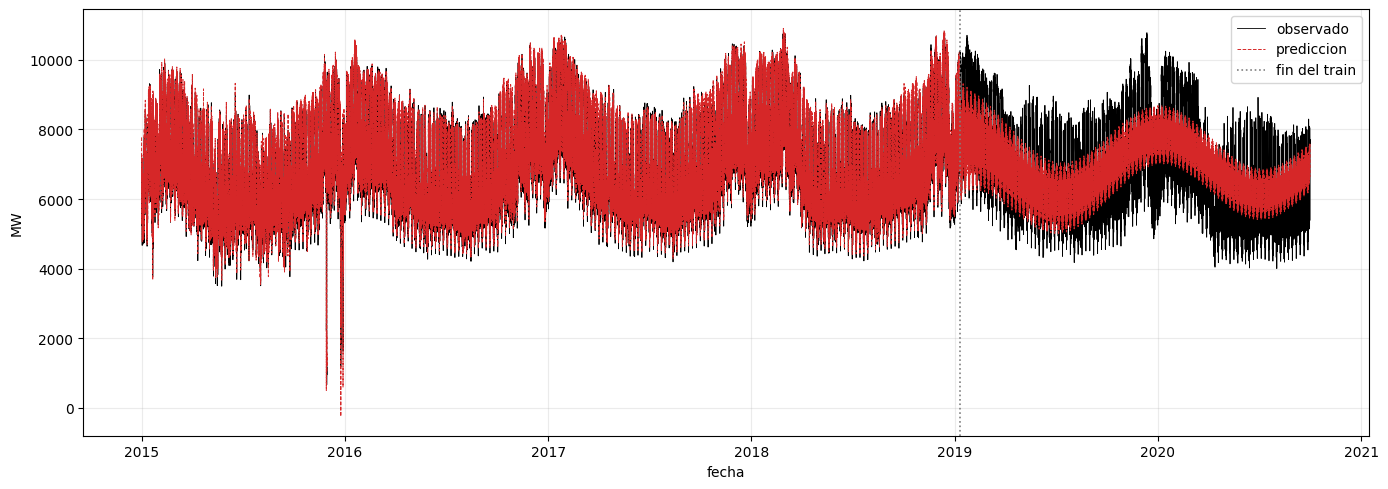

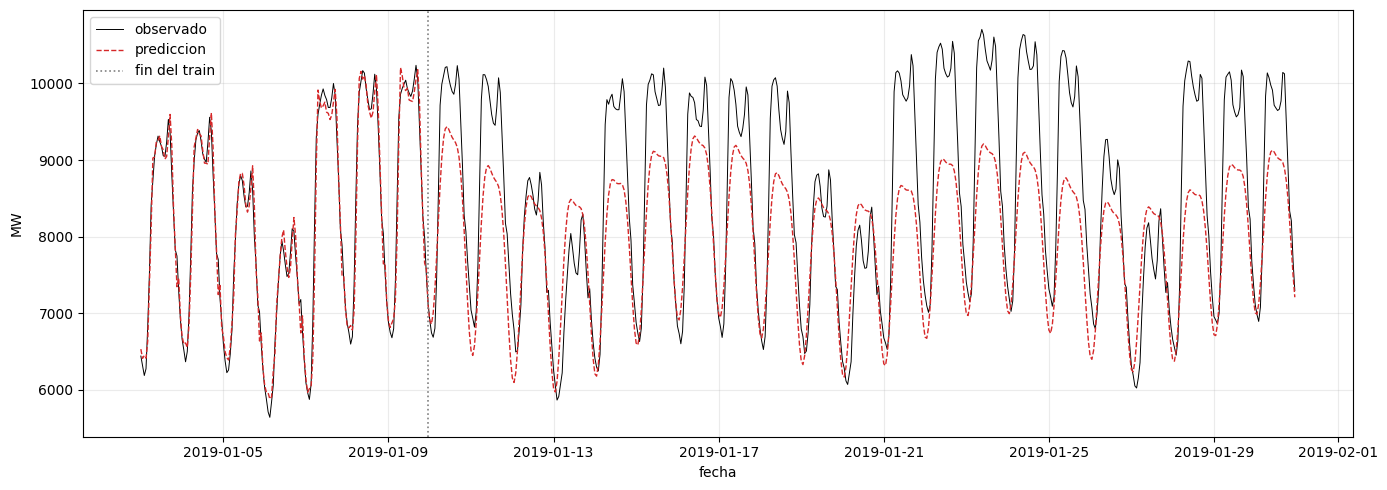

In [135]:
energy_3_8_9_prediction = predict_and_score(
    energy_3_8_9_model,
    "energy_3_8_9",
    "energy_model_3_8_fullpred.png",
    "energy_model_3_8_closepred.png",
    "Modelo con tres ciclos estocasticos y P_8(t)",
)

## Tratamiento determinista de los ciclos semanal y anual

In [122]:


energy_2_8_9_420_config = CyclicalTestConfig(
    n_deterministic_cycles=0,
    include_intercept=True,
    chebyshev_orders=(8,9, 420),  # P_8 (anual) + armonico semanal (=480 con split 80%)
    top_k=5,
    statistic_mode="test",
    stochastic_cycle_mode="multi_cycle",
    n_stochastic_cycles=2,
    ignored_stochastic_rs=(3,4,5,209,210,211),
    exclude_zero_frequency=True,
    error_model="white_noise",
    d_search_strategy="adaptive",
)

energy_2_8_9_420_model = fit_or_load_model("energy_model_2_8_420", energy_2_8_9_420_config)
summarize_test_result(energy_2_8_9_420_model, "Test con dos ciclos estocasticos y P_8(t), P_420(t)", T_train)
display(top_candidates_table(energy_2_8_9_420_model.result_, T_train, n=5))

Ajustando energy_model_2_8_420...
Ajuste completado en 3.99 min. Guardado en /Users/asierlanda/OneDrive - KPMG/Desktop/master/TFM/log_memory_cycles/models/energy_demand_notebook_match/energy_model_2_8_420.pkl
Test con dos ciclos estocasticos y P_8(t), P_420(t)
n_candidates_evaluated: 481
r_peak: 1470
r_candidates: [1470 2940]
test_value: -0.059759
test_star_value: -0.059982
variance_time: 56031.272498
variance_frequency: 55823.236184
betas: [ 35.799463 396.516295 -59.054594 331.137914]


,cycle,R,D,period_hours,period_days
0,1,1470,0.61,24.0,1.0
1,2,2940,0.19,12.0,0.5


,rank,test_value,abs_test_value,test_star_value,abs_test_star_value,xa,xaa,R_1,D_1,period_h_1,R_2,D_2,period_h_2
0,1,-0.059759,0.059759,-0.059982,0.059982,-71.618565,16.14009,1470,0.61,24.0,2940,0.19,12.0
1,2,-0.097021,0.097021,-0.097763,0.097763,-116.446425,16.14009,1470,0.64,24.0,2940,0.15,12.0
2,3,0.178079,0.178079,0.180853,0.180853,216.141910,16.14009,1470,0.67,24.0,2940,0.11,12.0
3,4,-0.190893,0.190893,-0.191092,0.191092,-230.862427,16.14009,1470,0.56,24.0,2940,0.26,12.0
4,5,0.251922,0.251922,0.252378,0.252378,303.149984,16.14009,1470,0.58,24.0,2940,0.23,12.0


In [123]:
# Significatividad de los betas del test con P_8(t) y P_420(t).
display(beta_significance_table(energy_2_8_9_420_model))

,coeficiente,beta,std_error,t_stat,critical_value,significativo
0,Intercepto,35.799463,8.325910,4.299766,1.645,True
1,P_8(t),396.516295,5.883182,67.398275,1.645,True
2,P_9(t),-59.054594,5.883192,-10.037850,1.645,True
3,P_420(t),331.137914,5.963712,55.525468,1.645,True


RMSE: 779.031
MAE:  611.753


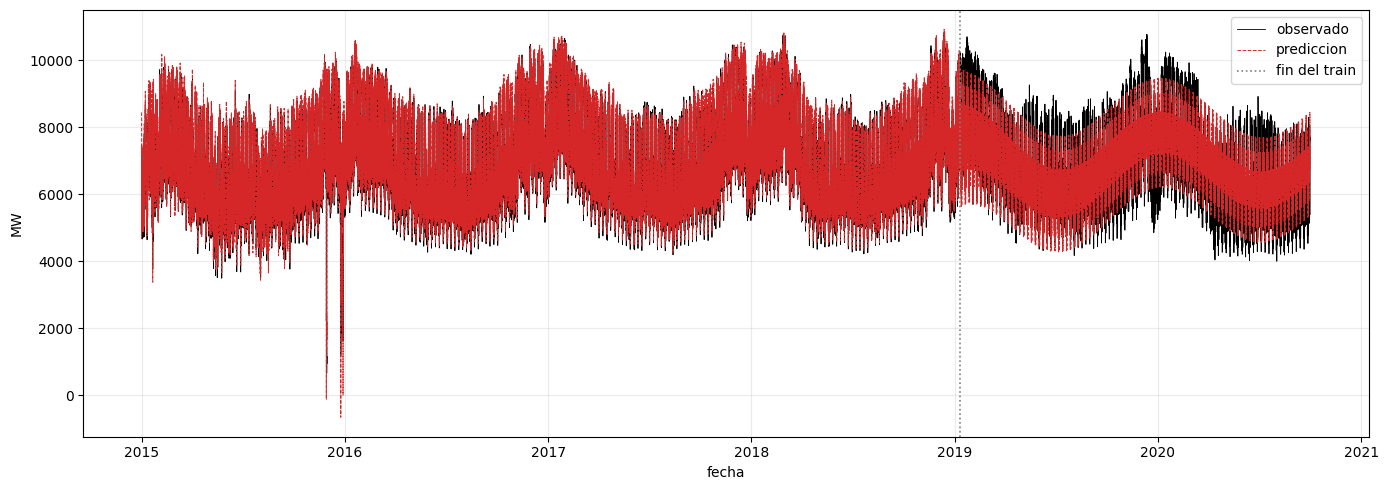

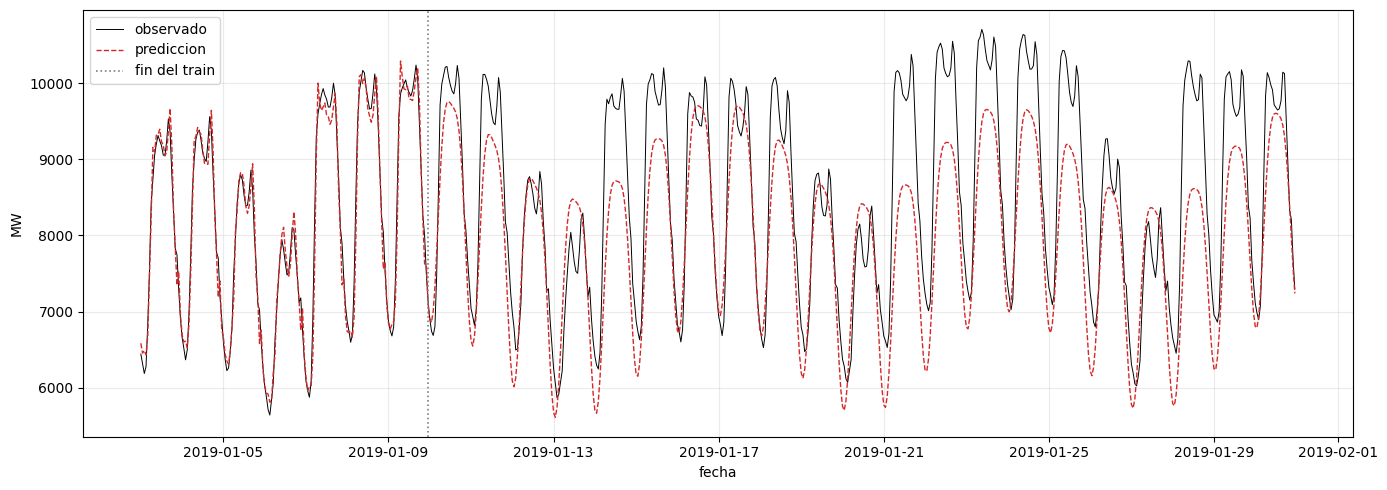

In [136]:
energy_2_8_9_420_prediction = predict_and_score(
    energy_2_8_9_420_model,
    "energy_2_8_9_420",
    "energy_model2_8_420_full.png",
    "energy_model_2_8_420_close.png",
    "Modelo con dos ciclos estocasticos y P_8(t), P_420(t)",
)

## Comparacion de especificaciones

In [ ]:
comparison = pd.DataFrame([
    {
        "modelo": "3 ciclos estocasticos",
        "RMSE": energy_3_0_prediction["rmse"],
        "MAE": energy_3_0_prediction["mae"],
        "cycles": [(c.R, c.D) for c in energy_3_0_model.cycles_],
        "betas": energy_3_0_model.betas_,
    },
    {
        "modelo": "2 ciclos estocasticos + P_8",
        "RMSE": energy_2_8_9_prediction["rmse"],
        "MAE": energy_2_8_9_prediction["mae"],
        "cycles": [(c.R, c.D) for c in energy_2_8_9_model.cycles_],
        "betas": energy_2_8_9_model.betas_,
    },
    {
        "modelo": "3 ciclos estocasticos + P_8",
        "RMSE": energy_3_8_9_prediction["rmse"],
        "MAE": energy_3_8_9_prediction["mae"],
        "cycles": [(c.R, c.D) for c in energy_3_8_9_model.cycles_],
        "betas": energy_3_8_9_model.betas_,
    },
    {
        "modelo": "2 ciclos estocasticos + P_8 + P_420",
        "RMSE": energy_2_8_9_420_prediction["rmse"],
        "MAE": energy_2_8_9_420_prediction["mae"],
        "cycles": [(c.R, c.D) for c in energy_2_8_9_420_model.cycles_],
        "betas": energy_2_8_9_420_model.betas_,
    },
])

display(comparison)
print(f"Figuras guardadas en: {FIG_DIR}")
print(f"Modelos/cache guardados en: {MODEL_DIR}")

,modelo,RMSE,MAE,cycles,betas
0,3 ciclos estocasticos,1050.052660,854.225240,"[(1470, 0.55), (4, 0.02), (210, 0.22)]",[]
1,2 ciclos estocasticos + P_8,853.907294,691.416747,"[(1470, 0.52), (210, 0.27)]","[6.66605038249818, 367.37629496302577, -87.656..."
2,3 ciclos estocasticos + P_8,884.775549,745.452722,"[(1470, 0.32), (210, 0.19), (2940, 0.21)]","[33.37099725643593, 394.0870419931779, -61.255..."
3,2 ciclos estocasticos + P_8 + P_420,779.030559,611.752981,"[(1470, 0.61), (2940, 0.19)]","[35.79946341176179, 396.51629540696484, -59.05..."


Figuras guardadas en: /Users/asierlanda/OneDrive - KPMG/Desktop/master/TFM/log_memory_cycles/figures/energy_demand
Modelos/cache guardados en: /Users/asierlanda/OneDrive - KPMG/Desktop/master/TFM/log_memory_cycles/models/energy_demand_notebook_match
